<a href="https://colab.research.google.com/github/johnlaraji1608-collab/fetalhealth_randomforest_classfication/blob/main/fetalhealth_randomforest_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/fetal_health.csv')

In [3]:
X = df.iloc[:, 0: -1].values
Y = df.iloc[:, -1].values
df.head(5)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
Y=Y.reshape(-1,1)
from sklearn.impute import SimpleImputer

In [5]:
imputerX = SimpleImputer(strategy = "mean", missing_values = np.nan)
imputerX = imputerX.fit(X[:,:])
X[:,:] = imputerX.transform(X[:,:])
imputerY = SimpleImputer(strategy = "mean", missing_values = np.nan)
imputerY = imputerY.fit(Y)
Y = imputerY.transform(Y)
Y = np.ravel(Y)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=10000, random_state=0 )
classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10000, random_state=0)

In [10]:
y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

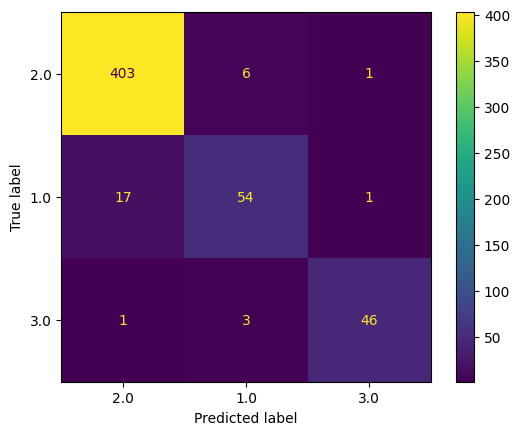

In [11]:
classes = df.fetal_health.unique()

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot()

plt.show()

In [12]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       410
         2.0       0.86      0.75      0.80        72
         3.0       0.96      0.92      0.94        50

    accuracy                           0.95       532
   macro avg       0.92      0.88      0.90       532
weighted avg       0.94      0.95      0.94       532

